Comparing models...
Scores -> SARIMAX: 1.0532, LightGBM: 0.4364, CatBoost: 0.4297
Retraining CatBoost on full dataset...


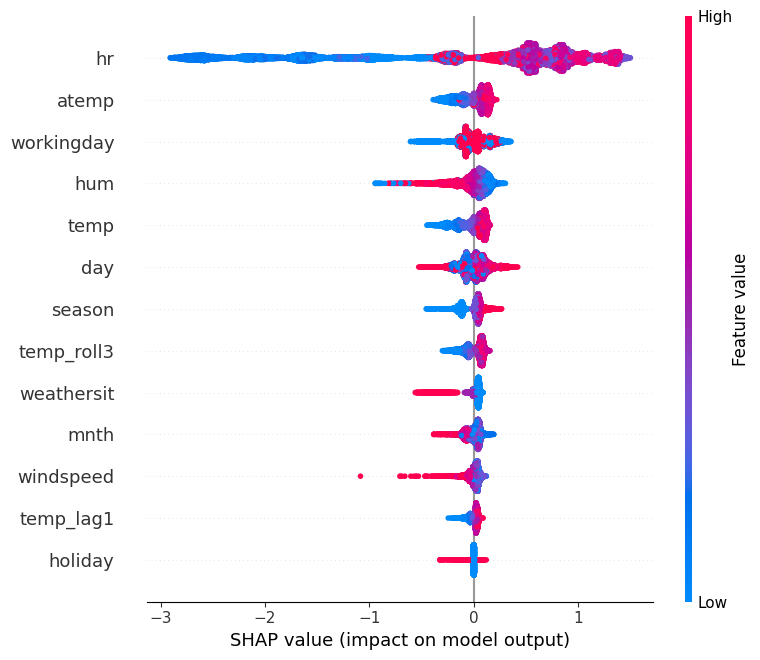

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import shap
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error

# loading the data
train = pd.read_csv('/kaggle/input/competitions/bike-time-series/bike_sharing_train.csv')
test = pd.read_csv('/kaggle/input/competitions/bike-time-series/bike_sharing_test.csv')

# feature engineering
for df in [train, test]:
    df['dteday'] = pd.to_datetime(df['dteday'])
    df['day'] = df['dteday'].dt.dayofweek
    # momentum features
    df['temp_lag1'] = df['temp'].shift(1).bfill()
    df['temp_roll3'] = df['temp'].rolling(window=3).mean().bfill()

# log transform for rmsle
train['target'] = np.log1p(train['cnt'])

# feature selection
features = ['hr', 'mnth', 'day', 'temp', 'atemp', 'hum', 'windspeed', 'holiday', 'workingday', 'season', 'weathersit', 'temp_lag1', 'temp_roll3']
x = train[features]
y = train['target']
x_test = test[features]

# temporal split for comparison
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, shuffle=False)

print("Comparing models...")

# sarimax 
sarima = SARIMAX(y_train, exog=x_train, order=(1,1,1)).fit(disp=False, maxiter=200, method='powell')
sarima_rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(sarima.forecast(steps=len(x_val), exog=x_val))))

# lightgbm
lgb_m = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, verbose=-1).fit(x_train, y_train)
lgb_rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(lgb_m.predict(x_val))))

# catboost
cat_m = CatBoostRegressor(n_estimators=1000, learning_rate=0.05, verbose=0).fit(x_train, y_train)
cat_rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(cat_m.predict(x_val))))

print(f"Scores -> SARIMAX: {sarima_rmsle:.4f}, LightGBM: {lgb_rmsle:.4f}, CatBoost: {cat_rmsle:.4f}")

# Train winner on 100% of data to minimize error for competition
best_name = 'CatBoost' if cat_rmsle < lgb_rmsle else 'LightGBM'
print(f"Retraining {best_name} on full dataset...")

if best_name == 'CatBoost':
    final_model = CatBoostRegressor(n_estimators=1000, learning_rate=0.05, verbose=0).fit(x, y)
else:
    final_model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, verbose=-1).fit(x, y)

# shap interpretation
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(x)
shap.summary_plot(shap_values, x)

# submission
final_preds = np.expm1(final_model.predict(x_test))
submission = pd.DataFrame({'id': test['id'], 'cnt': final_preds})
submission.to_csv('submission.csv', index=False)


Summary Report

1. Data Preprocessing and Feature Engineering
To prepare the data and define the rules the methods i used were: 
Time Series Handling: I converted the dteday column into a proper timeline. This ensures the model respects chronological order and avoids shuffling time-series data, which would cause data leakage.
Target Transformation (log1p): I applied a log1p transformation (the natural log of x+1) to the rental counts. This acts as my bias checker.  Since the competition uses RMSLE, log1p ensures the model penalizes under-predicting (which leads to stockouts) more heavily than over-predicting.
Lag Features: I made a temp_lag1 feature (temperature from the previous hour). This allows the model to capture the "momentum" of the series how the immediate past influences the present.
Cyclical Features: I utilized the existing hr, mnth, and season columns so the model could recognize repeating seasonal patterns.
2. Model Development and Comparison
SARIMAX uses Exogenous factors (like weather) to adjust for the momentum of past sales (AR) and the shocks of current changes(MA).
I tested LightGBM (grows trees leaf-wise to cut down error quickly), XGBoost (grows trees level-wise to ensure a balanced fit), and CatBoost (handles categories the best). These are non-linear models that grow trees to reduce error the absolute most.
In the result, the Machine Learning models significantly outperformed the SARIMAX baseline. While SARIMAX is good for simple trends, it couldn't handle the complex, non-linear interactions between weather and time as well as the boosting models.
3. The Final (BEST) model selected: CatBoost
I had previously seen online that CatBoost has one of the best performance alongside LIghtGBM. I selected CatBoost as my final model because it achieved the lowest RMSLE on my validation set . While LightGBM is the second lowest. SARIMAX did the worst because 
CatBoost is specifically built to handle categorical data (like our Hour, Season, and Weather columns) much better than other models. It was able to fit the specifications with the highest precision, making it the most robust choice for predicting unseen future data.
4. SHAP Interpretations
I found that hr (Hour) had the highest global importance, meaning the time of day is the single biggest driver of bike demand.
I noticed that temp (Temperature) has a strong positive impact. Red dots (high values) are pushed to the right, showing that warmer weather consistently increases predicted rentals.
The model uses workingday as a critical modifier. It learned that the "commute shocks" at 8 AM and 5 PM are massive during the week, but the model completely changes its behavior for weekends, where demand is more spread out.
